## Setup:

In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(0))

2.3.1
True
0
NVIDIA GeForce RTX 2080 Super with Max-Q Design


## Process

## PLM

Update protein name and choose model for PLM embedding

In [1]:
import os
from Bio import SeqIO
prot_name = 'TEM'
record = SeqIO.read('C:/Users/ese/EsmcBench/backend/EvolveTest/wt_fasta/'+prot_name+'_WT.fasta',"fasta")
wt_aa = record.seq
results_path =os.path.join('output',prot_name)
try:
    os.mkdir(results_path)
except OSError as error:
    print(error)
print(wt_aa)

[WinError 3] The system cannot find the path specified: 'output\\TEM'
MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIELDLNSGKILESFRPEERFPMMSTFKVLLCGAVLSRVDAGQEQLGRRIHYSQNDLVEYSPVTEKHLTDGMTVRELCSAAITMSDNTAANLLLTTIGGPKELTAFLHNMGDHVTRLDRWEPELNEAIPNDERDTTMPAAMATTLRKLLTGELLTLASRQQLIDWMEADKVAGPLLRSALPAGWFIADKSGAGERGSRGIIAALGPDGKPSRIVVIYTTGSQATMDERNRQIAEIGASLIKHW


In [2]:
os.chdir(r'C:\Users\ese\EvolvePro')
from evolvepro.src.process import generate_wt, generate_single_aa_mutants
generate_wt(wt_aa, output_file=f'output/{prot_name}/{prot_name}_WT.fasta')
generate_single_aa_mutants(f'output/{prot_name}/{prot_name}_WT.fasta', output_file=f'output/{prot_name}/{prot_name}.fasta')

Number of mutants: 5435


In [7]:
import pandas as pd
import pathlib
import json
def reformat_embeddings(prot_name,model):
        #print(file)
        embeddings_dir = "C:/Users/ese/EvolvePro/output/"
        end_dir = 'C:/Users/ese/EsmcBench/backend/EvolveTest'
        embeddings_path = os.path.join(embeddings_dir,prot_name,f"{prot_name}_{model}.csv")
        end_dir = os.path.join(end_dir,prot_name)
        try:
            os.mkdir(end_dir)
        except OSError as error:
            error
        end_dir = os.path.join(end_dir,'embeddings',f"{prot_name}_{model}.csv")
        df = pd.read_csv(embeddings_path)
        df['embedding'] = df[df.columns[1:]].apply(lambda r: json.dumps(list(r)), axis=1)
        df.rename(columns={'Unnamed: 0': 'seq_id'})[['seq_id', 'embedding']]\
            .replace('WT Wild-type sequence','WT')\
            .to_csv(end_dir, index=False)

In [4]:
import subprocess
models = [
    #'esm1b_t33_650M_UR50S',
    #'esm1v_t33_650M_UR90S_1',
    #'esm1v_t33_650M_UR90S_2',
    #'esm1v_t33_650M_UR90S_3',
    #'esm1v_t33_650M_UR90S_4',
    #'esm1v_t33_650M_UR90S_5',
    'esm2_t6_8M_UR50D',
    'esm2_t12_35M_UR50D',
    'esm2_t30_150M_UR50D',
    #'esm2_t33_650M_UR50D'
]
for model in models:
    try:
        plm_cmd = f"python evolvepro/plm/esm/extract.py {model} output/{prot_name}/{prot_name}.fasta output/{prot_name}/{prot_name}_{model} --toks_per_batch 1024 --include mean --concatenate_dir output/{prot_name}"
        print(plm_cmd)
        result = subprocess.run(plm_cmd, shell=True, capture_output=True, text=True)
        print("Return Code:", result.returncode)
        print("Standard Output:", result.stdout)
        print("Standard Error:", result.stderr)
    except:
        continue
for model in models:
    try:
        reformat_embeddings(prot_name,model)
    except:
        continue



python evolvepro/plm/esm/extract.py esm2_t6_8M_UR50D output/TEM/TEM.fasta output/TEM/TEM_esm2_t6_8M_UR50D --toks_per_batch 1024 --include mean --concatenate_dir output/TEM
Return Code: 0
Standard Output: Transferred model to GPU
Read output\TEM\TEM.fasta with 5435 sequences
Processing 1 of 1812 batches (3 sequences)
Device: cuda:0
Processing 2 of 1812 batches (3 sequences)
Device: cuda:0
Processing 3 of 1812 batches (3 sequences)
Device: cuda:0
Processing 4 of 1812 batches (3 sequences)
Device: cuda:0
Processing 5 of 1812 batches (3 sequences)
Device: cuda:0
Processing 6 of 1812 batches (3 sequences)
Device: cuda:0
Processing 7 of 1812 batches (3 sequences)
Device: cuda:0
Processing 8 of 1812 batches (3 sequences)
Device: cuda:0
Processing 9 of 1812 batches (3 sequences)
Device: cuda:0
Processing 10 of 1812 batches (3 sequences)
Device: cuda:0
Processing 11 of 1812 batches (3 sequences)
Device: cuda:0
Processing 12 of 1812 batches (3 sequences)
Device: cuda:0
Processing 13 of 1812 batc

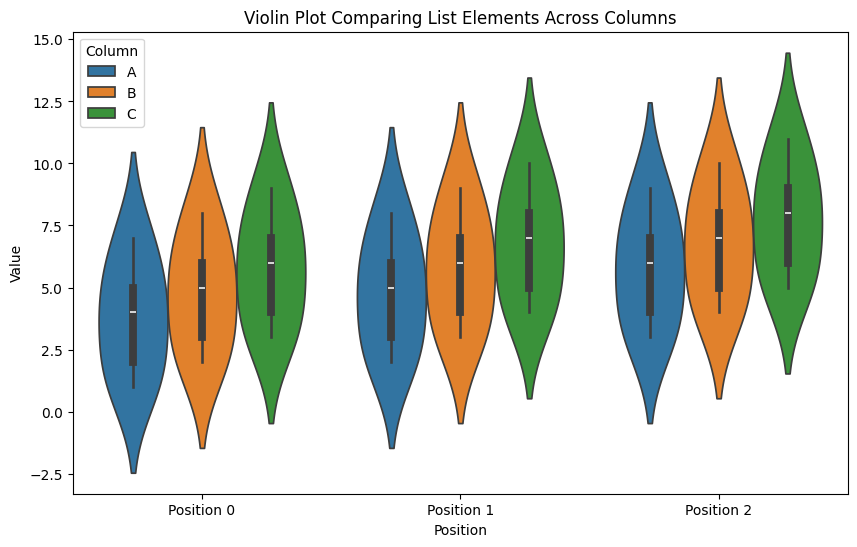

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'A': [[1,2,3], [4,5,6], [7,8,9], [2,3,4], [5,6,7]],
    'B': [[2,3,4], [5,6,7], [8,9,10], [3,4,5], [6,7,8]],
    'C': [[3,4,5], [6,7,8], [9,10,11], [4,5,6], [7,8,9]]
})

# First, we need to restructure the data
def reshape_for_violin(df):
    # Create empty lists for the new structure
    values = []
    positions = []
    columns = []
    
    # Iterate through each column
    for col in df.columns:
        # Iterate through each row's list
        for row in df[col]:
            # Iterate through each position in the list
            for i, value in enumerate(row):
                values.append(value)
                positions.append(f'Position {i}')
                columns.append(col)
    
    # Create a new dataframe with the restructured data
    return pd.DataFrame({
        'Value': values,
        'Position': positions,
        'Column': columns
    })

# Reshape the data
reshaped_df = reshape_for_violin(df)

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=reshaped_df, x='Position', y='Value', hue='Column')
plt.title('Violin Plot Comparing List Elements Across Columns')
plt.show()

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [8 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "C:\Users\ese\AppData\Local\Temp\pip-install-18enhx79\ast_b42647e2987f4795a98e0729fd3c0d99\setup.py", line 6, in <module>
          README = codecs.open(os.path.join(here, 'AST/README'), encoding='utf8').read()
        File "c:\Users\ese\miniforge3\envs\plm\lib\codecs.py", line 906, in open
          file = builtins.open(filename, mode, buffering)
      FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\ese\\AppData\\Local\\Temp\\pip-install-18enhx79\\ast_b42647e2987f4795a98e0729fd3c0d99\\AST/README'
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while gener

In [1]:
import pandas as pd

data = {
    'rubisco_esm1b_t33_650M_UR50S.csv': [
        [1, 2, 9], [1, 2, 17], [2, 2, 12], [1, 14, 14], [1, 3, 3],
        [2, 3, 5], [1, 1, 1], [1, 1, 13], [1, 7, 17], [1, 2, 2],
        [1, 1, 12], [1, 5, 6], [1, 1, 2], [1, 6, 8], [1, 2, 2],
        [1, 2, 2], [1, 1, 1, 1], [3, 3, 3], [1, 1, 1, 1], [1, 7, 7],
        [1, 2, 2], [1, 2, 2], [1, 1, 1], [1, 1, 1], [1, 3, 3],
        [1, 9, 24], [1, 4, 4], [4, 5, 6], [1, 3, 9], [1, 1, 1],
        [1, 7, 11, 11], [2, 6, 11], [2, 2, 2], [1, 2, 2], [1, 1, 3],
        [1, 1, 2], [1, 7, 7, 7], [1, 3, 3], [1, 4, 4], [1, 2, 4],
        [1, 1, 4], [1, 1, 2], [1, 5, 5], [1, 1, 1], [1, 4, 4],
        [1, 1, 1], [1, 2, 14], [2, 4, 6], [2, 4, 4], [3, 3, 11]
    ],
    'rubisco_esm1v_t33_650M_UR90S_1.csv': [
        [1, 4, 4], [1, 11, 11], [1, 11, 11], [1, 4, 8], [1, 5, 6],
        [1, 2, 23], [1, 11, 23], [1, 7, 7], [1, 2, 17], [2, 2, 7],
        [1, 6, 6], [1, 6, 6], [1, 1, 11], [1, 4, 4], [1, 1, 14],
        [1, 2, 10], [1, 3, 8], [3, 3, 4], [1, 7, 10], [2, 2, 2],
        [1, 9, 12], [1, 1, 1], [1, 6, 23], [1, 1, 1], [1, 1, 12],
        [1, 7, 12], [2, 4, 4], [5, 6, 11], [1, 2, 2], [1, 1, 13],
        [1, 1, 1], [1, 4, 4], [1, 4, 4, 4], [2, 4, 4], [1, 4, 9],
        [1, 1, 1], [2, 2, 11], [3, 3, 3], [1, 5, 5], [1, 11, 24],
        [1, 1, 4], [1, 9, 28], [1, 1, 11], [1, 3, 5], [2, 8, 11],
        [1, 1, 1], [1, 1, 8], [1, 1, 1], [1, 18, 18], [1, 6, 6]
    ],
    'rubisco_esm1v_t33_650M_UR90S_2.csv': [
        [1, 4, 4], [1, 4, 4], [1, 4, 4], [4, 12, 12], [2, 12, 14],
        [1, 1, 9], [1, 2, 4], [1, 1, 3], [1, 3, 3], [1, 7, 8],
        [2, 2, 2], [2, 11, 12], [1, 3, 11], [4, 18, 18], [1, 6, 6],
        [1, 1, 1], [2, 4, 4], [1, 1, 5], [1, 4, 4], [1, 1, 1],
        [1, 3, 3], [1, 1, 1], [1, 6, 20], [1, 18, 26], [1, 3, 3],
        [1, 2, 29], [1, 1, 4], [7, 15, 15], [2, 5, 20], [1, 3, 3],
        [1, 8, 9], [1, 1, 17], [1, 4, 4], [2, 6, 6], [2, 2, 5],
        [1, 1, 23], [4, 4, 4], [2, 7, 29], [1, 1, 19], [1, 3, 5, 5],
        [3, 3, 13], [2, 5, 5], [1, 5, 5], [2, 14, 18], [1, 2, 2],
        [1, 5, 5], [3, 13, 13], [1, 4, 4], [1, 1, 16], [1, 3, 3]
    ],
    'rubisco_esm1v_t33_650M_UR90S_3.csv': [
        [5, 5, 10], [1, 2, 2, 2], [2, 4, 4], [3, 3, 10], [1, 2, 2],
        [1, 1, 30], [1, 2, 3], [3, 6, 6], [3, 3, 4], [2, 2, 2],
        [2, 3, 3], [1, 3, 3], [1, 1, 1], [3, 4, 16], [1, 2, 5],
        [3, 5, 5], [1, 1, 8], [2, 2, 2], [1, 3, 3, 3], [2, 9, 9],
        [1, 4, 4], [1, 2, 2], [1, 5, 6], [3, 5, 5], [1, 3, 4],
        [1, 7, 7], [6, 6, 8], [1, 1, 4], [1, 1, 4], [1, 1, 2],
        [2, 3, 7], [1, 1, 4], [1, 8, 8], [2, 4, 7, 7], [1, 1, 1],
        [1, 3, 4], [4, 5, 10], [4, 5, 11], [1, 4, 4], [2, 4, 4],
        [1, 6, 6], [1, 1, 1], [1, 7, 7], [1, 9, 13], [1, 1, 4],
        [2, 6, 6], [2, 3, 3], [1, 1, 10], [1, 4, 9], [1, 3, 8]
    ],
    'rubisco_esm1v_t33_650M_UR90S_4.csv': [
        [1, 2, 2], [1, 3, 3], [1, 3, 3], [1, 3, 6], [1, 1, 1],
        [6, 19, 43], [1, 6, 6], [2, 2, 10], [1, 2, 3], [1, 9, 29],
        [1, 2, 3], [1, 1, 6], [1, 1, 2], [2, 6, 6], [1, 9, 9],
        [1, 2, 2], [1, 15, 37], [1, 10, 12], [1, 4, 5], [1, 1, 6],
        [2, 6, 6], [1, 3, 13], [1, 1, 7], [1, 3, 3], [1, 4, 11],
        [1, 1, 2], [1, 5, 5], [1, 1, 16], [1, 1, 2], [1, 2, 8],
        [2, 3, 11, 11], [1, 1, 2], [1, 2, 6], [2, 4, 7], [1, 5, 6],
        [1, 1, 2], [1, 1, 9], [1, 4, 4], [3, 5, 8], [1, 1, 2],
        [2, 4, 5], [1, 7, 12], [1, 6, 6], [1, 3, 3], [2, 4, 15],
        [1, 4, 5], [1, 3, 3], [2, 4, 4], [1, 1, 8], [1, 2, 2]
    ]
}

df = pd.DataFrame(data)

# Save to CSV if needed
#df.to_csv('output.csv', index=False)

# Display first few rows
print(df.head())

  rubisco_esm1b_t33_650M_UR50S.csv rubisco_esm1v_t33_650M_UR90S_1.csv  \
0                        [1, 2, 9]                          [1, 4, 4]   
1                       [1, 2, 17]                        [1, 11, 11]   
2                       [2, 2, 12]                        [1, 11, 11]   
3                      [1, 14, 14]                          [1, 4, 8]   
4                        [1, 3, 3]                          [1, 5, 6]   

  rubisco_esm1v_t33_650M_UR90S_2.csv rubisco_esm1v_t33_650M_UR90S_3.csv  \
0                          [1, 4, 4]                         [5, 5, 10]   
1                          [1, 4, 4]                       [1, 2, 2, 2]   
2                          [1, 4, 4]                          [2, 4, 4]   
3                        [4, 12, 12]                         [3, 3, 10]   
4                        [2, 12, 14]                          [1, 2, 2]   

  rubisco_esm1v_t33_650M_UR90S_4.csv  
0                          [1, 2, 2]  
1                          [1, 3

In [48]:
import pandas as pd
import ast

# Read the Excel file into a DataFrame
df = pd.read_excel(r'C:\Users\ese\EsmcBench\backend\EvolveTest\rubisco\50rd\rubisco_50rd.xlsx')

# Function to convert string representations of lists to actual lists
def convert_to_list(value):
    if isinstance(value, str) and value.startswith('[') and value.endswith(']'):
        try:
            return ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return value
    return value

# Convert all string representations of lists to actual lists
df = df.applymap(convert_to_list)

# Function to modify lists with exactly four elements
def modify_lists(df):
    # Iterate over each column
    for col in df.columns:
        # Iterate over each row in the column
        for i, row in enumerate(df[col]):
            # Check if the row is a list and has exactly four elements
            if isinstance(row, list) and len(row) == 4:
                # Remove the last element
                df.at[i, col] = row[:-1]
    return df

# Modify the DataFrame
df_modified = modify_lists(df)

# Print the modified DataFrame
print(df_modified)

   rubisco_esm1b_t33_650M_UR50S.csv rubisco_esm1v_t33_650M_UR90S_1.csv  \
0                         [1, 2, 9]                          [1, 4, 4]   
1                        [1, 2, 17]                        [1, 11, 11]   
2                        [2, 2, 12]                        [1, 11, 11]   
3                       [1, 14, 14]                          [1, 4, 8]   
4                         [1, 3, 3]                          [1, 5, 6]   
5                         [2, 3, 5]                         [1, 2, 23]   
6                         [1, 1, 1]                        [1, 11, 23]   
7                        [1, 1, 13]                          [1, 7, 7]   
8                        [1, 7, 17]                         [1, 2, 17]   
9                         [1, 2, 2]                          [2, 2, 7]   
10                       [1, 1, 12]                          [1, 6, 6]   
11                        [1, 5, 6]                          [1, 6, 6]   
12                        [1, 1, 2]   

C:\Users\ese\AppData\Local\Temp\ipykernel_6844\4119389553.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(convert_to_list)


['Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile', 'Above WT', '50th Percentile', '90th Percentile',

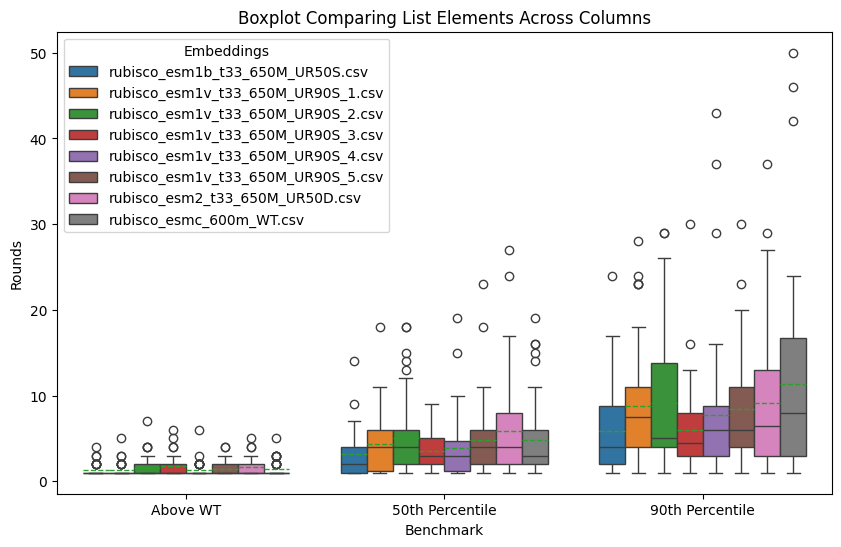

Text(0.5, 1.0, 'Violinplot Comparing List Elements Across Columns')

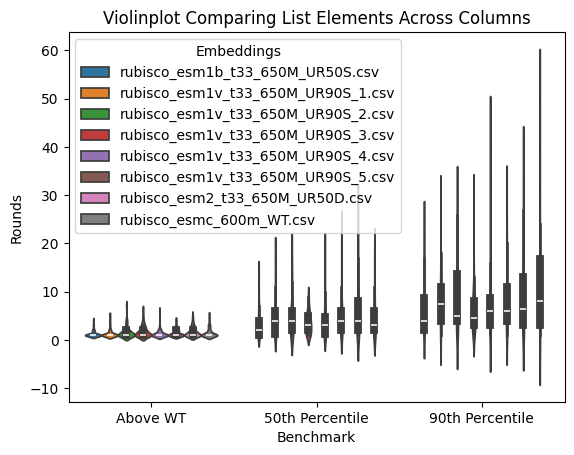

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
wt_activity = 1
benchmarks = {
    'Above WT' : wt_activity,
    '50th Percentile' : 0.5,
    '90th Percentile' : 0.9,
    '95th Percentile' : 0.95,
}
# First, we need to restructure the data
def reshape_for_violin(df,benchmarks):
    # Create empty lists for the new structure
    values = []
    positions = []
    columns = []
    
    # Iterate through each column
    for col in df.columns:
        # Iterate through each row's list
        for row in df[col]:
            # Iterate through each position in the list
            try:
                for i, value in enumerate(row):
                    values.append(value)
                    positions.append(list(benchmarks.keys())[i])
                    columns.append(col)
            except:
                continue
    print(positions)
    # Create a new dataframe with the restructured data
    return pd.DataFrame({
        'Rounds': values,
        'Benchmark': positions,
        'Embeddings': columns
    })

# Reshape the data
reshaped_df = reshape_for_violin(df_modified)
print(reshaped_df)
# Create the violin plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=reshaped_df, showmeans=True, meanline = True, meanprops={"markerfacecolor":"black"}, x='Benchmark', y='Rounds', hue='Embeddings')
plt.title('Boxplot Comparing List Elements Across Columns')
plt.show()
sns.violinplot(data=reshaped_df, x='Benchmark', y='Rounds', hue='Embeddings')
plt.title('Violinplot Comparing List Elements Across Columns')

Text(0, 0.5, '')

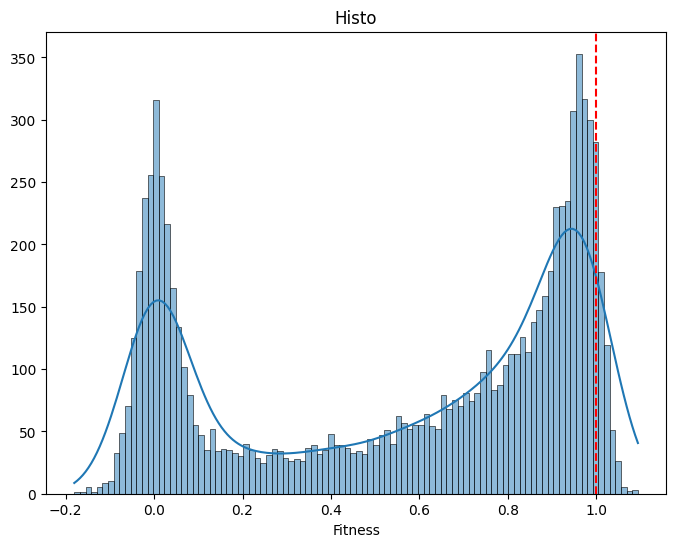

In [51]:
df = pd.read_excel(r'C:\Users\ese\EsmcBench\backend\EvolveTest\DMS_data\rubisco_dms.xlsx')
df = df.sort_values('activity', ascending=True)
#print(df)

plt.figure(figsize=(8, 6))
sns.histplot(df['activity'],bins=100,kde=True)
#wt_activity =1  # Replace with your specific value
#plt.axvline(x=wt_activity, color='0.0', linestyle='--', label=f'WT')
dead = 1  # Replace with your specific value
plt.axvline(x=dead, color='r', linestyle='--', label=f'WT')

# Add titles and labels
plt.title(f'{exp} Variant Fitness Distribution')
plt.xlabel('Fitness')
plt.ylabel('')